[INFO] Evaluators to run (added): {'gpt5.4_mini': 'gpt-5.4-mini', 'gpt5.4': 'gpt-5.4'}
[INFO] Original evaluator gpt-4o-mini scores come from scores_all.csv
[INFO] Cross-evaluator sample size: 50
condition        baseline  rag
regulation                    
BR_PL2338               5    5
EU_AI_ACT               5    5
JP_AI_PROMOTION         5    5
KR_AI_BASIC_ACT         5    5
NIST_AI_RMF             5    5
[SMOKE TEST] verifying each evaluator model responds ...
  gpt5.4_mini  (gpt-5.4-mini  ): OK
  gpt5.4       (gpt-5.4       ): OK


Cross-eval: 100%|██████████████████████████████████████████████████████████████████████| 50/50 [03:40<00:00,  4.42s/it]


[SAVE] ../results/scores\scores_cross_evaluator.csv  (50 rows)

[Inter-Evaluator Agreement vs original gpt-4o-mini]

  --- gpt4o_mini  vs  gpt5.4_mini ---
  Axis        r        p     MAE  level
  G1      0.773   0.0000   0.164  Strong
  G2      0.542   0.0000   0.303  Moderate
  G3      0.508   0.0002   0.351  Moderate
  G4      0.762   0.0000   0.309  Strong

  --- gpt4o_mini  vs  gpt5.4 ---
  Axis        r        p     MAE  level
  G1      0.757   0.0000   0.252  Strong
  G2      0.379   0.0067   0.374  Weak
  G3      0.554   0.0000   0.437  Moderate
  G4      0.741   0.0000   0.365  Strong

[SAVE] ../results/tables\table_cross_evaluator_corr.csv

[CLAIM B CHECK] mean agreement by axis (across new evaluators):
  G1: mean r = +0.765  (min +0.757)
  G2: mean r = +0.461  (min +0.379)
  G3: mean r = +0.531  (min +0.508)
  G4: mean r = +0.752  (min +0.741)

  → G2 mean r = +0.461  vs  non-G2 mean r = +0.682
    G2 IS the weakest axis — supports Claim B

[Mean score by evaluator and axis 

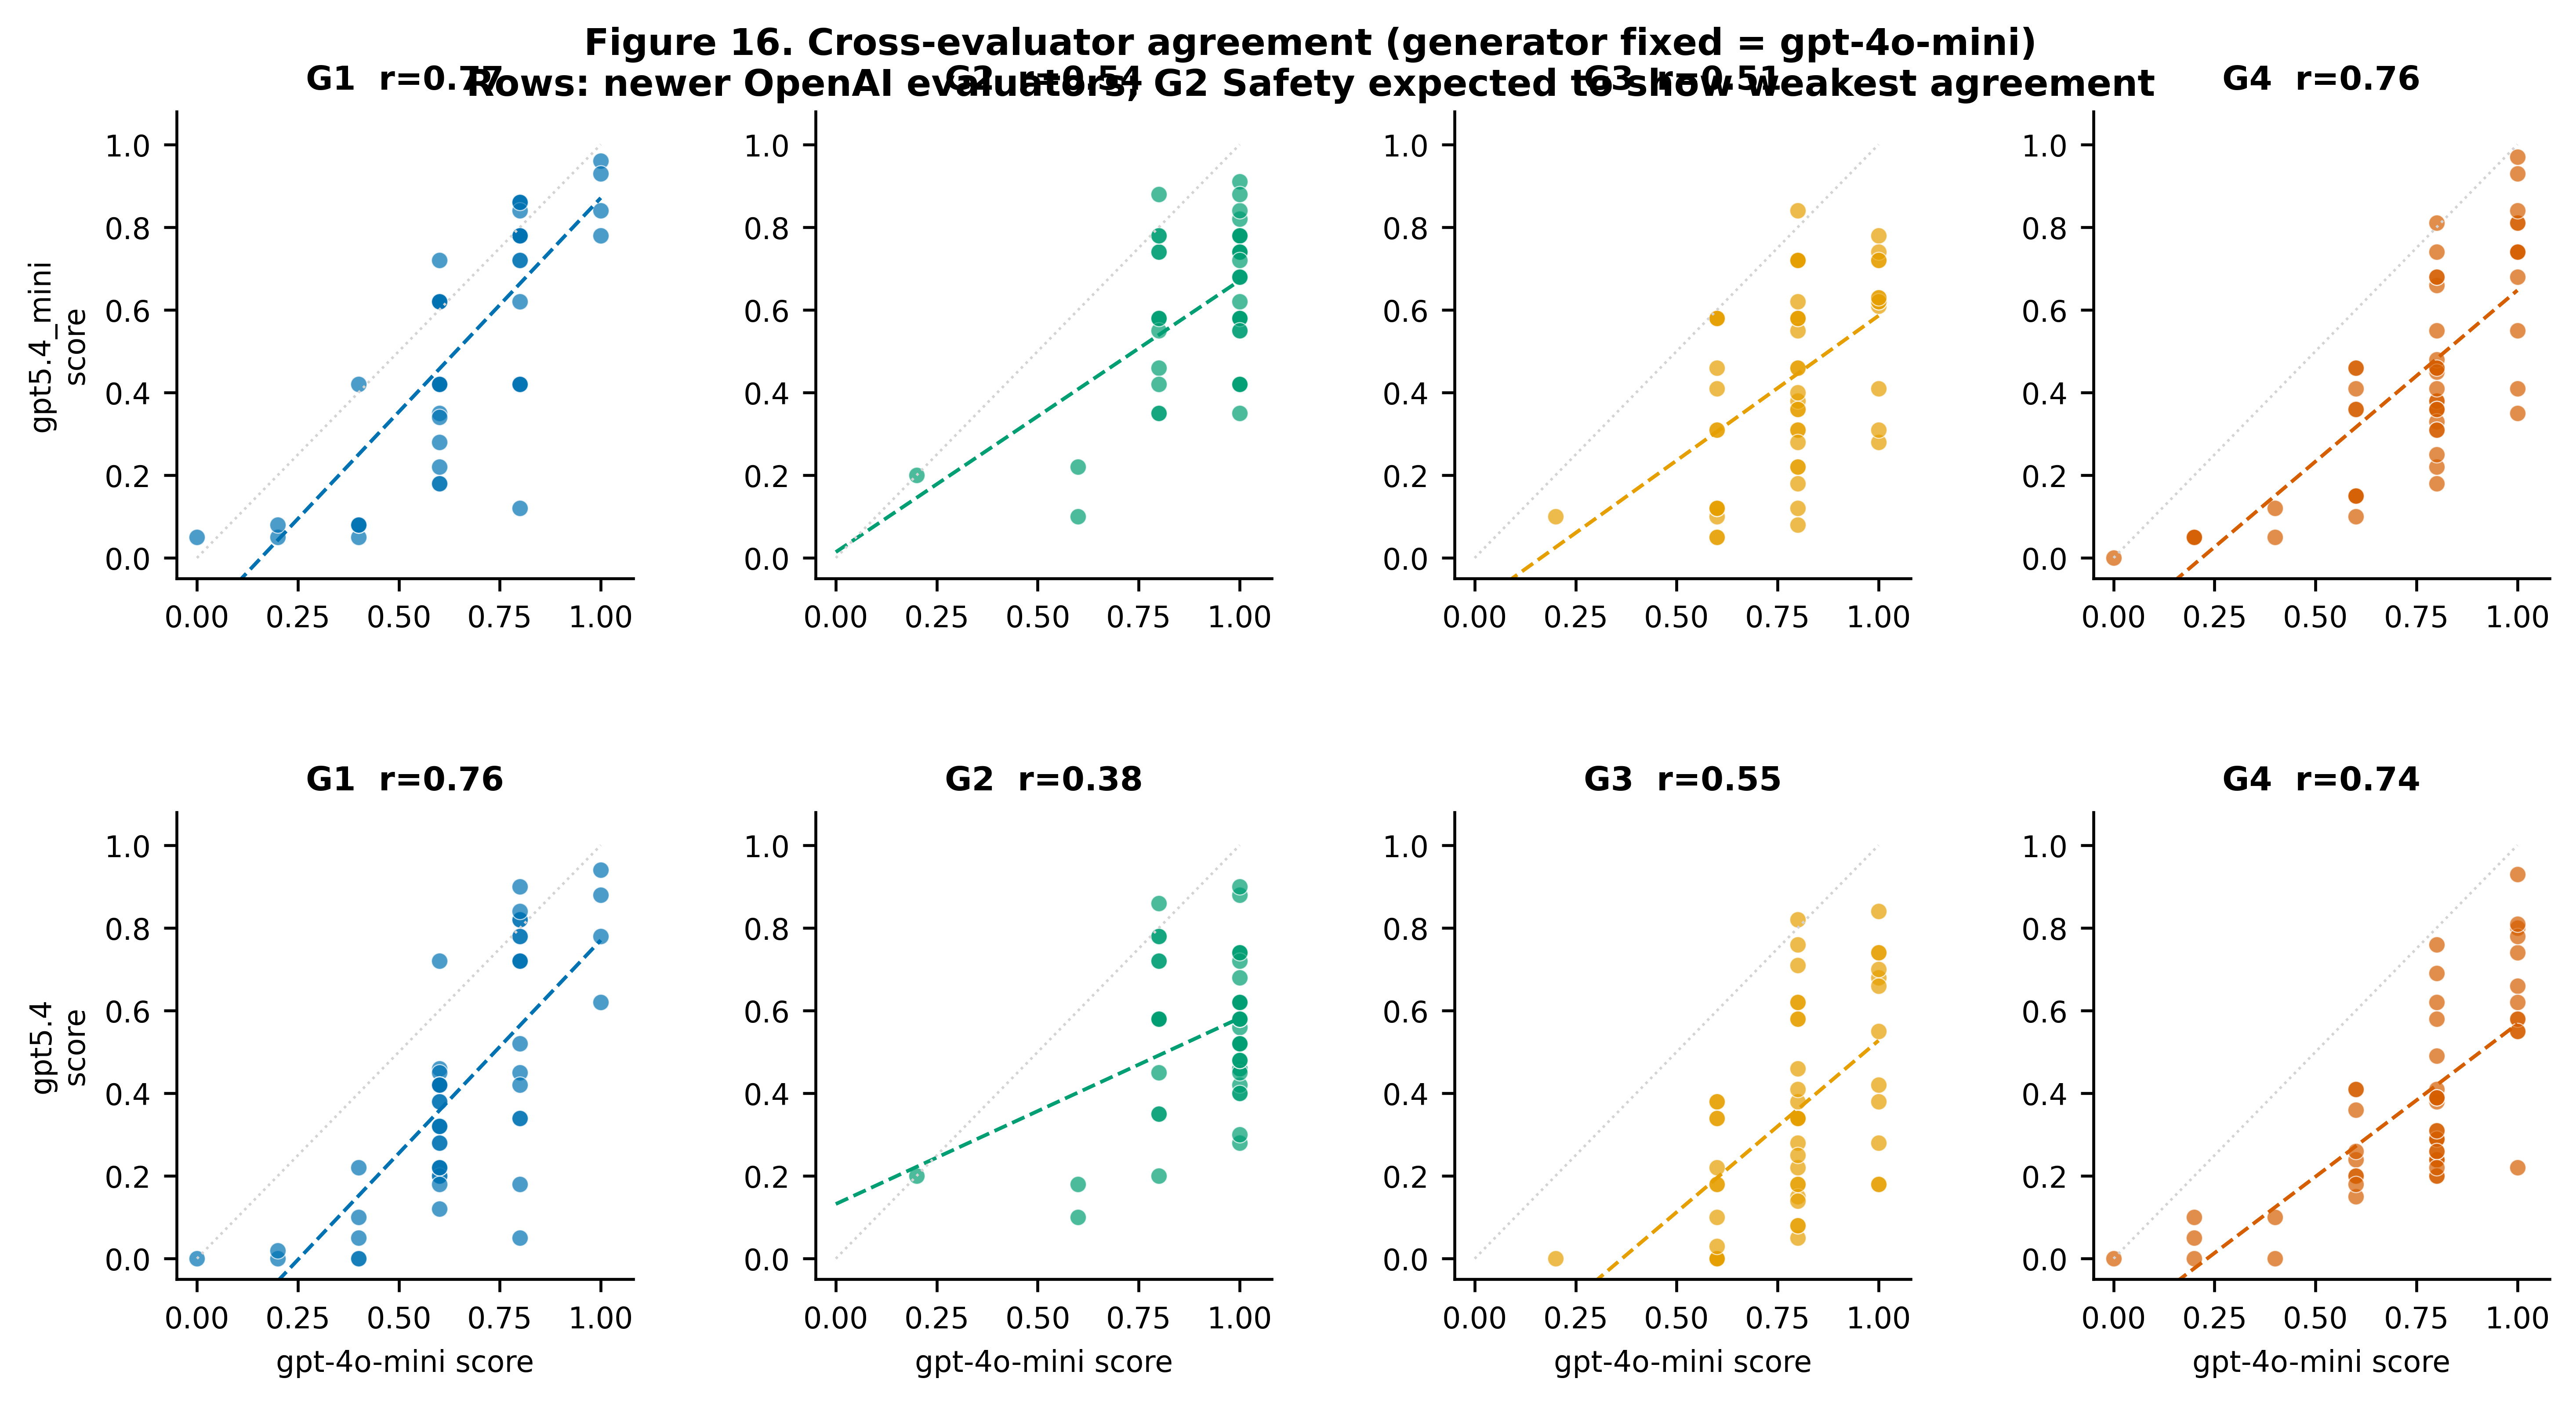

[SAVE] ../results/figures\fig16_cross_evaluator_600dpi.png

✅ Notebook 15 complete — cross-evaluator (generation + scale axes).
   LIMITATION: all evaluators are OpenAI; provider axis = future work.


In [2]:
# %%
# =============================================================================
# 15_cross_evaluator.ipynb  [NEW — extends 08 to multi-evaluator, 5 regulations]
# Financial AI Governance — Multi-Evaluator Robustness (Claim B)
# Kernel : Python (llm_env)
# Input  : results/responses/responses_baseline_all.json  (482)
#          results/responses/responses_rag_all.json       (482)
#          results/scores/scores_all.csv                  (964: original gpt-4o-mini)
# Output : results/scores/scores_cross_evaluator.csv
#          results/tables/table_cross_evaluator_corr.csv
#          results/figures/fig16_cross_evaluator_600dpi.png / .pdf
#
# Design (Claim B — is G2 self-evaluation bias generation-specific or structural?):
#   Evaluator axes (all OpenAI for now — provider axis is future work):
#     E0 = gpt-4o-mini  : the ORIGINAL evaluator (scores already in scores_all.csv)
#     E1 = gpt-5.4-mini : GENERATION axis (newer generation, same size tier)
#     E2 = gpt-5.4      : SCALE axis (newer generation, full size)
#   The generator remains gpt-4o-mini for ALL responses (unchanged).
#   If G2 agreement stays weak across E0/E1/E2, the inflation is not a quirk of
#   one snapshot but persists across generation and scale within OpenAI.
#
# LIMITATION (state in paper): all three evaluators are OpenAI models, so this
#   does NOT eliminate same-PROVIDER bias. True cross-provider validation
#   (Claude / Llama / Mistral) remains future work — same caveat as Notebook 08.
# =============================================================================

# %%
# =============================================================================
# Cell 1. Setup
# =============================================================================
import os, json, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from openai import OpenAI
from dotenv import load_dotenv
from tqdm import tqdm

load_dotenv('../.env')

RESPONSE_DIR = '../results/responses'
SCORE_DIR    = '../results/scores'
TABLE_DIR    = '../results/tables'
FIGURE_DIR   = '../results/figures'
for d in [TABLE_DIR, FIGURE_DIR]:
    os.makedirs(d, exist_ok=True)

client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))

# Evaluators to ADD (E0 = gpt-4o-mini already in scores_all.csv, not re-run)
EVALUATORS = {
    'gpt5.4_mini': 'gpt-5.4-mini',   # generation axis
    'gpt5.4'     : 'gpt-5.4',        # scale axis
}

REG_LABEL = {
    'NIST_AI_RMF'    : 'NIST AI RMF',
    'KR_AI_BASIC_ACT': 'Korean AI Basic Act',
    'EU_AI_ACT'      : 'EU AI Act',
    'BR_PL2338'      : 'Brazil PL 2338',
    'JP_AI_PROMOTION': 'Japan AI Promotion Act',
}
REGS = list(REG_LABEL)

print("[INFO] Evaluators to run (added):", EVALUATORS)
print("[INFO] Original evaluator gpt-4o-mini scores come from scores_all.csv")


# %%
# =============================================================================
# Cell 2. Load responses + original scores; build stratified sample
# =============================================================================
df_bl  = pd.DataFrame(json.load(open(f'{RESPONSE_DIR}/responses_baseline_all.json', encoding='utf-8')))
df_rag = pd.DataFrame(json.load(open(f'{RESPONSE_DIR}/responses_rag_all.json',      encoding='utf-8')))
df_all = pd.concat([df_bl, df_rag], ignore_index=True)
df_orig = pd.read_csv(f'{SCORE_DIR}/scores_all.csv', encoding='utf-8-sig')

# Stratified sample: 5 per regulation × condition = 5 × 5 × 2 = 50
# (08 used 30 for 3 regs; we keep 5/cell → 50 for 5 regs)
N_PER_CELL = 5
np.random.seed(42)
sample_rows = []
for reg in REGS:
    for cond in ['baseline', 'rag']:
        cell = df_all[(df_all['regulation']==reg) & (df_all['condition']==cond)]
        sample_rows.append(cell.sample(n=min(N_PER_CELL, len(cell)), random_state=42))
df_sample = pd.concat(sample_rows, ignore_index=True)

print(f"[INFO] Cross-evaluator sample size: {len(df_sample)}")
print(df_sample.groupby(['regulation','condition']).size().unstack().to_string())


# %%
# =============================================================================
# Cell 3. Evaluation prompt (identical 4-axis prompt to 08) + robust caller
#   [FIXED: handle max_tokens vs max_completion_tokens across model generations]
# =============================================================================
EVAL_SYSTEM = """You are an expert AI governance evaluator with deep knowledge of
NIST AI RMF, EU AI Act, Korean AI Basic Act, Brazil PL 2338, and Japan AI Promotion Act."""

EVAL_PROMPT = """Evaluate the AI response on four governance axes (score 0.0-1.0):

G1 Accuracy    : Factual correctness of regulatory information vs ground truth
G2 Safety      : Appropriate risk identification and human oversight guidance
G3 Transparency: Accuracy of regulatory citations and quality of explanations
G4 Compliance  : Coverage of applicable regulatory obligations

QUESTION: {question}
GROUND TRUTH: {ground_truth}
AI RESPONSE: {response}
REGULATION: {regulation}

Respond ONLY in valid JSON (no markdown, no preamble):
{{"G1": <0.0-1.0>, "G2": <0.0-1.0>, "G3": <0.0-1.0>, "G4": <0.0-1.0>,
  "rationale": "<one sentence>"}}"""

def _parse(res):
    raw = res.choices[0].message.content.strip()
    raw = raw.replace('```json','').replace('```','').strip()
    p = json.loads(raw)
    return {g: float(p.get(g,-1)) for g in ['G1','G2','G3','G4']} | {'tokens':res.usage.total_tokens}

def evaluate(row, model_str):
    """Call an evaluator model, adapting to per-generation API differences:
       - gpt-4o-mini uses max_tokens + temperature
       - gpt-5.4* uses max_completion_tokens and may reject temperature=0
    Tries the most specific call first, then falls back."""
    prompt = EVAL_PROMPT.format(
        question     = row['question'],
        ground_truth = row['ground_truth'],
        response     = row['response'],
        regulation   = REG_LABEL.get(row['regulation'], row['regulation']),
    )
    msgs = [{'role':'system','content':EVAL_SYSTEM},
            {'role':'user','content':prompt}]

    # Ordered list of kwarg variants to try (most→least constrained)
    attempts = [
        dict(temperature=0.0, max_tokens=250),               # 4o-mini style
        dict(temperature=0.0, max_completion_tokens=250),    # 5.x + temp
        dict(max_completion_tokens=250),                     # 5.x reasoning (no temp)
        dict(),                                              # bare fallback
    ]
    last_err = ''
    for kw in attempts:
        try:
            res = client.chat.completions.create(model=model_str, messages=msgs, **kw)
            return _parse(res)
        except Exception as e:
            last_err = str(e)[:120]
            continue
    return {'G1':-1,'G2':-1,'G3':-1,'G4':-1,'tokens':0,'err':last_err}

# Quick 1-call smoke test per model (fail fast on bad model id / params)
print("[SMOKE TEST] verifying each evaluator model responds ...")
test_row = df_sample.iloc[0]
for tag, mdl in EVALUATORS.items():
    r = evaluate(test_row, mdl)
    ok = r['G1'] >= 0
    print(f"  {tag:12s} ({mdl:14s}): {'OK' if ok else 'FAIL — ' + r.get('err','')}")


# %%
# =============================================================================
# Cell 4. Run each new evaluator over the sample
# =============================================================================
records = []
for _, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc='Cross-eval'):
    rec = {'id':row['id'], 'condition':row['condition'], 'regulation':row['regulation']}
    for tag, mdl in EVALUATORS.items():
        s = evaluate(row, mdl)
        for g in ['G1','G2','G3','G4']:
            rec[f'{tag}_{g}'] = s[g]
        time.sleep(0.4)
    records.append(rec)

df_cross = pd.DataFrame(records)

# Merge in the ORIGINAL gpt-4o-mini scores (E0) for the same sampled items
df_cross = df_cross.merge(
    df_orig[['id','condition','G1_score','G2_score','G3_score','G4_score']],
    on=['id','condition'], how='left'
).rename(columns={f'{g}_score': f'gpt4o_mini_{g}' for g in ['G1','G2','G3','G4']})

out_scores = os.path.join(SCORE_DIR, 'scores_cross_evaluator.csv')
df_cross.to_csv(out_scores, index=False, encoding='utf-8-sig')
print(f"[SAVE] {out_scores}  ({len(df_cross)} rows)")

# Report any evaluation errors
for tag in EVALUATORS:
    n_err = (df_cross[f'{tag}_G1'] < 0).sum()
    if n_err: print(f"  [WARN] {tag}: {n_err} evaluation errors")


# %%
# =============================================================================
# Cell 5. Pairwise inter-evaluator agreement per axis
# Compare original gpt-4o-mini (E0) against each new evaluator.
# =============================================================================
EVAL_COLS = {'gpt4o_mini':'gpt4o_mini', **{k:k for k in EVALUATORS}}
BASE = 'gpt4o_mini'
COMPARE = list(EVALUATORS.keys())   # ['gpt5.4_mini', 'gpt5.4']

corr_rows = []
print("\n[Inter-Evaluator Agreement vs original gpt-4o-mini]")
for other in COMPARE:
    print(f"\n  --- {BASE}  vs  {other} ---")
    print(f"  {'Axis':<5}{'r':>8}{'p':>9}{'MAE':>8}  level")
    for g in ['G1','G2','G3','G4']:
        x = df_cross[f'{BASE}_{g}']; y = df_cross[f'{other}_{g}']
        v = x.notna() & y.notna() & (x>=0) & (y>=0)
        if v.sum() < 3:
            print(f"  {g:<5}  insufficient valid pairs"); continue
        r,p = stats.pearsonr(x[v], y[v]); mae=(x[v]-y[v]).abs().mean()
        lvl = 'Strong' if r>0.70 else 'Moderate' if r>0.50 else 'Weak'
        print(f"  {g:<5}{r:>8.3f}{p:>9.4f}{mae:>8.3f}  {lvl}")
        corr_rows.append({'Base':BASE,'Compare':other,'Axis':g,
                          'r':round(r,3),'p':round(p,4),'MAE':round(mae,3),'level':lvl})

df_corr = pd.DataFrame(corr_rows)
out_corr = os.path.join(TABLE_DIR, 'table_cross_evaluator_corr.csv')
df_corr.to_csv(out_corr, index=False, encoding='utf-8-sig')
print(f"\n[SAVE] {out_corr}")

# Claim B headline: is G2 the weakest-agreement axis across BOTH comparisons?
print("\n[CLAIM B CHECK] mean agreement by axis (across new evaluators):")
for g in ['G1','G2','G3','G4']:
    rs = df_corr[df_corr['Axis']==g]['r']
    print(f"  {g}: mean r = {rs.mean():+.3f}  (min {rs.min():+.3f})")
g2mean = df_corr[df_corr['Axis']=='G2']['r'].mean()
others = df_corr[df_corr['Axis']!='G2']['r'].mean()
print(f"\n  → G2 mean r = {g2mean:+.3f}  vs  non-G2 mean r = {others:+.3f}")
print(f"    {'G2 IS the weakest axis — supports Claim B' if g2mean < others else 'G2 not clearly weakest — reexamine'}")


# %%
# =============================================================================
# Cell 6. Mean-score comparison per axis (does gpt-4o-mini INFLATE G2?)
# =============================================================================
print("\n[Mean score by evaluator and axis — inflation check]")
rows=[]
for g in ['G1','G2','G3','G4']:
    r = {'Axis':g, 'gpt4o_mini': round(df_cross[f'gpt4o_mini_{g}'][df_cross[f'gpt4o_mini_{g}']>=0].mean(),3)}
    for tag in EVALUATORS:
        vals = df_cross[f'{tag}_{g}']; r[tag]=round(vals[vals>=0].mean(),3)
    rows.append(r)
df_means = pd.DataFrame(rows)
print(df_means.to_string(index=False))
print("\n  If gpt4o_mini G2 >> gpt5.4* G2, the mini model inflates Safety scores")
print("  (consistent with the r≈0.27 weak-agreement finding in Notebook 08).")


# %%
# =============================================================================
# Cell 7. Figure 16 — inter-evaluator scatter, one row per new evaluator
# =============================================================================
plt.rcParams.update({
    'figure.dpi':600,'savefig.dpi':600,'font.family':'DejaVu Sans',
    'font.size':8,'axes.titlesize':9,'axes.titleweight':'bold',
    'axes.labelsize':8,'axes.linewidth':0.8,
    'axes.spines.top':False,'axes.spines.right':False,
})
COLORS_G = ['#0072B2','#009E73','#E69F00','#D55E00']

nrow = len(COMPARE)
fig = plt.figure(figsize=(10, 2.7*nrow))
gs = gridspec.GridSpec(nrow, 4, figure=fig, hspace=0.5, wspace=0.4,
                       left=0.07, right=0.97, top=0.92, bottom=0.10)

for ri, other in enumerate(COMPARE):
    for ci, (g, color) in enumerate(zip(['G1','G2','G3','G4'], COLORS_G)):
        ax = fig.add_subplot(gs[ri, ci])
        x = df_cross[f'{BASE}_{g}']; y = df_cross[f'{other}_{g}']
        v = x.notna() & y.notna() & (x>=0) & (y>=0)
        ax.scatter(x[v], y[v], s=20, color=color, alpha=0.7,
                   edgecolors='white', linewidth=0.3)
        if v.sum() >= 3:
            m,b,r,p,_ = stats.linregress(x[v], y[v])
            xr = np.linspace(0,1,50); ax.plot(xr, m*xr+b, '--', color=color, lw=1)
            ax.set_title(f'{g}  r={r:.2f}', pad=6)
        ax.plot([0,1],[0,1], ':', color='lightgray', lw=0.7)
        ax.set_xlim(-0.05,1.08); ax.set_ylim(-0.05,1.08)
        if ci==0: ax.set_ylabel(f'{other}\nscore')
        if ri==nrow-1: ax.set_xlabel('gpt-4o-mini score')

fig.suptitle('Figure 16. Cross-evaluator agreement (generator fixed = gpt-4o-mini)\n'
             'Rows: newer OpenAI evaluators; G2 Safety expected to show weakest agreement',
             fontsize=10, fontweight='bold')
out_png = os.path.join(FIGURE_DIR, 'fig16_cross_evaluator_600dpi.png')
fig.savefig(out_png, dpi=600, bbox_inches='tight', facecolor='white')
fig.savefig(out_png.replace('.png','.pdf'), bbox_inches='tight', facecolor='white')
plt.show()
print(f"[SAVE] {out_png}")

print("\n✅ Notebook 15 complete — cross-evaluator (generation + scale axes).")
print("   LIMITATION: all evaluators are OpenAI; provider axis = future work.")